In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

In [2]:
#setting seed to ensure repeatability of runs 

#np.random.seed(42)
#random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.600000          7.300000        8.000000   
1      1            2.594582          7.657056        8.119968   
2      2            2.659435          8.079050        8.310268   
3      3            2.794976          8.552439        8.556792   
4      4            2.024511          6.807095        6.536751   
..   ...                 ...               ...             ...   
15    15            3.107948         11.094201        6.260703   
16    16            3.670215         12.337967        6.574833   
17    17            4.226404         13.647729        6.854916   
18    18            4.733438         14.973370        7.157461   
19    19            5.182607         16.239712        7.397165   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               17.900000                89.100000                43.300000   
1               18.371607        

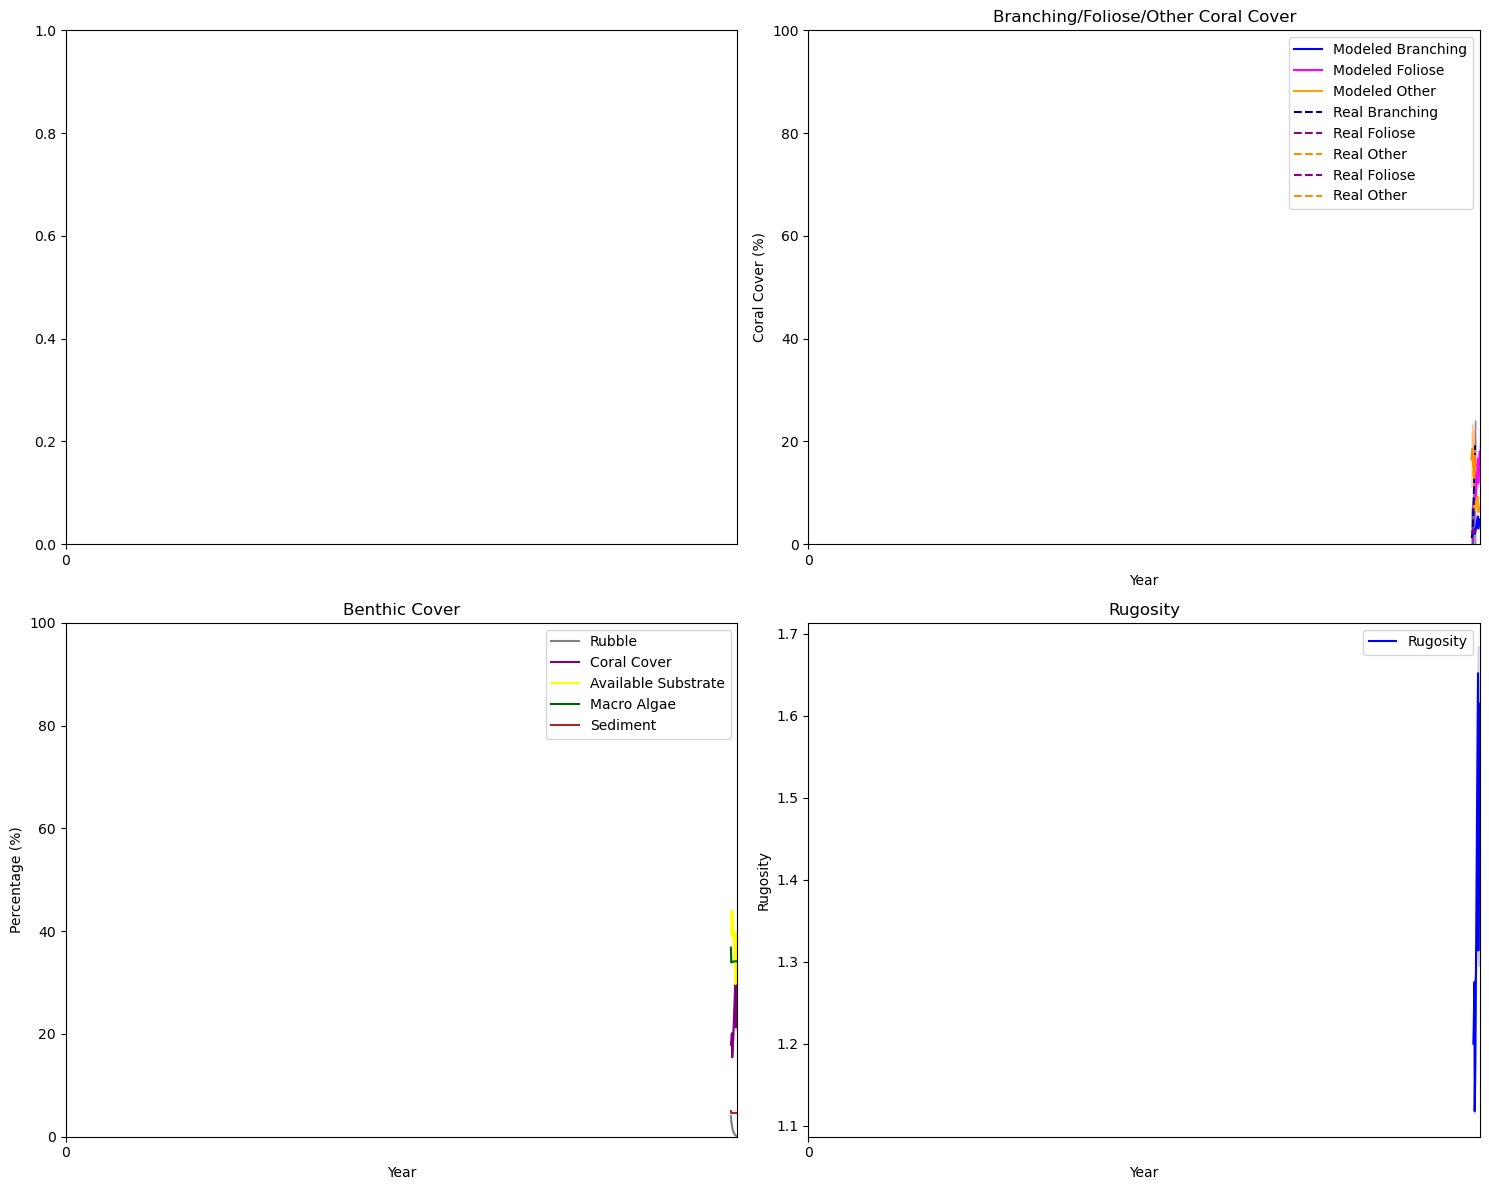

In [3]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Ensure all relevant columns are numeric and handle NaNs
for col in ['Branching_Area (%)', 'Foliose_Area (%)', 'Other_Area (%)', 'Total_Coral_Cover (%)']:
	final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
for col in ['RealBranching_Area (%)', 'RealFoliose_Area (%)', 'RealOther_Area (%)', 'Total_Coral_Cover (%)']:
	real_df[col] = pd.to_numeric(real_df[col], errors='coerce')

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Fill NaNs with 0 (or use .dropna() if you prefer to remove them)
average_branching = average_branching.fillna(0)
std_dev_branching = std_dev_branching.fillna(0)
average_foliose = average_foliose.fillna(0)
std_dev_foliose = std_dev_foliose.fillna(0)
average_other = average_other.fillna(0)
std_dev_other = std_dev_other.fillna(0)
average_total = average_total.fillna(0)
std_dev_total = std_dev_total.fillna(0)

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Ensure all arrays are strictly float and NaNs are handled
average_total_arr = np.array(average_total, dtype=float)
std_dev_total_arr = np.array(std_dev_total, dtype=float)
real_years_arr = np.array(real_df['Year'], dtype=float)
real_total_coral_cover_arr = np.array(real_df['Total_Coral_Cover (%)'], dtype=float)

# Fill NaNs with 0
average_total_arr = np.nan_to_num(average_total_arr)
std_dev_total_arr = np.nan_to_num(std_dev_total_arr)
real_years_arr = np.nan_to_num(real_years_arr)
real_total_coral_cover_arr = np.nan_to_num(real_total_coral_cover_arr)

# Plot Total Coral Cover
# Ensure all arrays are strictly float and NaNs are handled
average_branching_arr = np.array(average_branching, dtype=float)
std_dev_branching_arr = np.array(std_dev_branching, dtype=float)
average_foliose_arr = np.array(average_foliose, dtype=float)
std_dev_foliose_arr = np.array(std_dev_foliose, dtype=float)
average_other_arr = np.array(average_other, dtype=float)
std_dev_other_arr = np.array(std_dev_other, dtype=float)
real_branching_arr = np.array(real_df['RealBranching_Area (%)'], dtype=float)
real_foliose_arr = np.array(real_df['RealFoliose_Area (%)'], dtype=float)
real_other_arr = np.array(real_df['RealOther_Area (%)'], dtype=float)

average_branching_arr = np.nan_to_num(average_branching_arr)
std_dev_branching_arr = np.nan_to_num(std_dev_branching_arr)
average_foliose_arr = np.nan_to_num(average_foliose_arr)
std_dev_foliose_arr = np.nan_to_num(std_dev_foliose_arr)
average_other_arr = np.nan_to_num(average_other_arr)
std_dev_other_arr = np.nan_to_num(std_dev_other_arr)
real_branching_arr = np.nan_to_num(real_branching_arr)
real_foliose_arr = np.nan_to_num(real_foliose_arr)
real_other_arr = np.nan_to_num(real_other_arr)

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching_arr, label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, average_branching_arr - std_dev_branching_arr, average_branching_arr + std_dev_branching_arr, color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose_arr, label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, average_foliose_arr - std_dev_foliose_arr, average_foliose_arr + std_dev_foliose_arr, color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other_arr, label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, average_other_arr - std_dev_other_arr, average_other_arr + std_dev_other_arr, color='orange', alpha=0.2)
axs[0, 1].plot(real_years_arr, real_branching_arr, label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_years_arr, real_branching_arr - real_branching_margin, real_branching_arr + real_branching_margin, color='darkblue', alpha=0.2)
axs[0, 1].plot(real_years_arr, real_foliose_arr, label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_years_arr, real_foliose_arr - real_foliose_margin, real_foliose_arr + real_foliose_margin, color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_years_arr, real_other_arr, label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_years_arr, real_other_arr - real_other_margin, real_other_arr + real_other_margin, color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])
# Convert real_df columns to float numpy arrays before plotting
real_years_float = np.array(real_df['Year'], dtype=float)
real_branching_float = np.array(real_df['RealBranching_Area (%)'], dtype=float)
real_foliose_float = np.array(real_df['RealFoliose_Area (%)'], dtype=float)
real_other_float = np.array(real_df['RealOther_Area (%)'], dtype=float)

axs[0, 1].fill_between(real_years_float, real_branching_float - real_branching_margin, real_branching_float + real_branching_margin, color='darkblue', alpha=0.2)
axs[0, 1].plot(real_years_float, real_foliose_float, label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_years_float, real_foliose_float - real_foliose_margin, real_foliose_float + real_foliose_margin, color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_years_float, real_other_float, label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_years_float, real_other_float - real_other_margin, real_other_float + real_other_margin, color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# After your plotting code:
# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

NameError: name 'title' is not defined

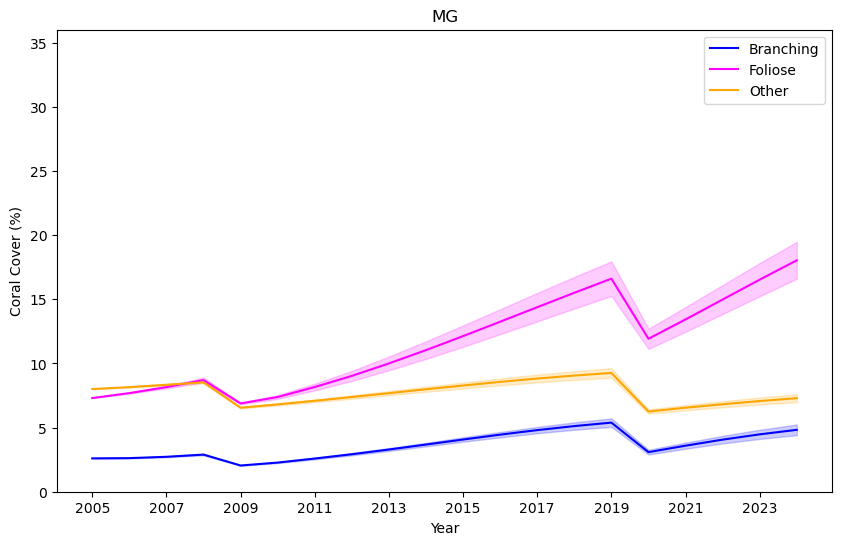

In [4]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

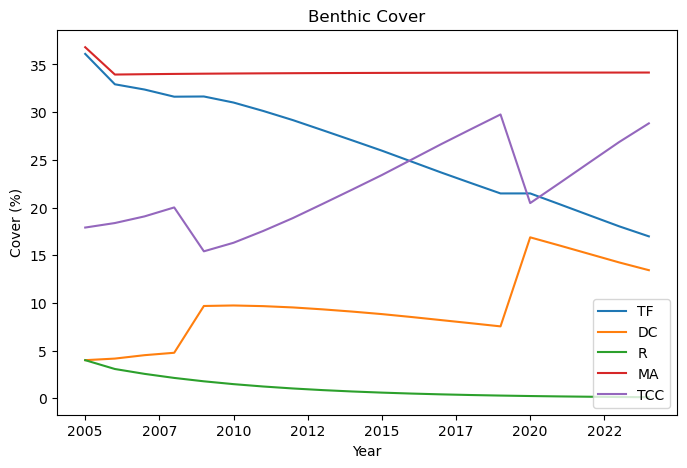

In [5]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

NameError: name 'title' is not defined

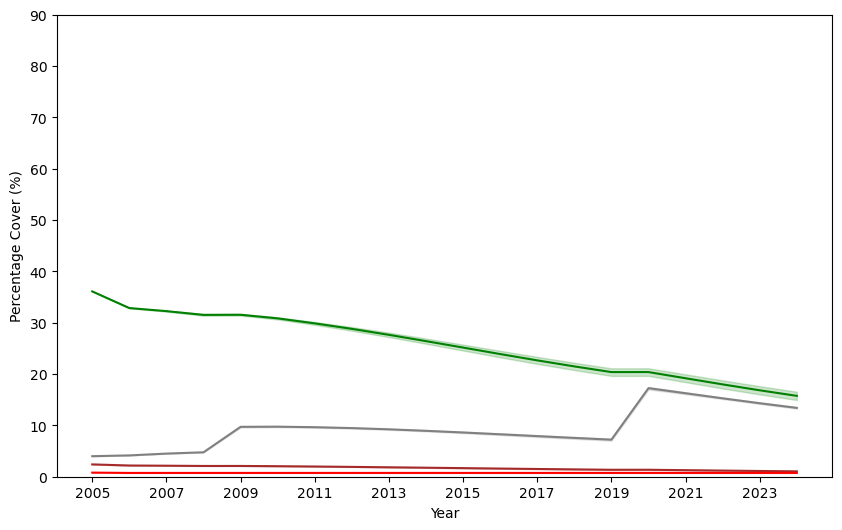

In [6]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")